# Research Notebook Week 1
## Ferdinand Soong

# 1: Experience

The goal of this week was testing out different temperature models from the Gasteldello paper and find the best one to fit our data. 
Each one of us was tasked with trying one of 3 Equations
Smoothly joined power law (Eq. 4)
Power laws mediated by exponentials (Eq. 5)
RiseFall model (Eq 6)
## Motivation:

The main goal is to test the SIDM model on larger galaxies. This is done by assuming a hydrostatic equilibrium of the DM particles and solving the ODE which comes from the ideal gas equation:
\begin{equation}
    \frac{dP_{gas}}{dr}=-\frac{GM_{tot}(r)\rho_{gas}(r)}{r^2}
\end{equation}
The temperature will be used to switch out the pressure in the equation and getting the gas density $\rho_g$ for which we solve to compare our results with the observational data.

# 2: What? (What happened?)
## Describe what happened during your activities for the week.
I implemented the Equation number 4 as code:

\begin{equation}
T(r) = \frac{1}{\left[ \left( \frac{1}{t_1(r)} \right)^s + \left( \frac{1}{t_2(r)} \right)^s \right]^{\frac{1}{s}}}
\end{equation}
\begin{equation}
t_i(r)=T_{i,100}(\frac{r}{100kpc})^{p_i} \quad \quad i=1,2
\end{equation}

import numpy as np

def temperature_model(r, T1_100, T2_100, p1, p2, s):
    """
    Smoothly joined power-law temperature model.

    Parameters:
    r : Radius in kpc
    T1_100, T2_100 : normalization at 100kpc
    p1, p2 : Power-law slopes
    s : Smoothing parameter

    Returns:
    T(r) :  Temperature
    """
    
    t1 = T1_100 * (r / 100.0)**p1
    t2 = T2_100 * (r / 100.0)**p2
    
    T = ( (1 / t1**s) + (1 / t2**s) )**(-1 / s)
    
    return T
Then had it read the csv file to get the data:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


data = pd.read_excel(FILE, sheet_name=SYSTEM)

data["R"]       = 0.5 * (data["R1 (kpc)"] + data["R2 (kpc)"])
data["Error R"] = 0.5 * (data["R2 (kpc)"] - data["R1 (kpc)"])

ch = data[data["Source"] == "Chandra"].copy()
xm = data[data["Source"] == "XMM"].copy()

and finally plotted the model 


plt.figure()

plt.errorbar(r, T_obs, yerr=T_err, fmt='o', label="Data")
plt.plot(r_fit, T_fit, label="Model Fit")

plt.xlabel("Radius (kpc)")
plt.ylabel("Temperature")
plt.title("Temperature Profile Fit")
plt.legend()

plt.show()

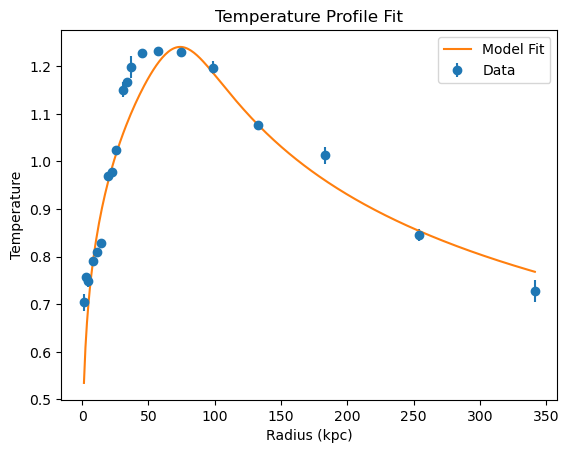

# 3: So what? (What does it mean?)
## Describe your results

The plot shows significant descrepancies at around 50kpc to the observational data. It would have to be checked if other galaxies or models have the same problem. 

# 4. Now what? (What's next?)
## Plan for the next week

The next step would be to try more galaxies and compare the results with the other models to find the best one.

# 5. Bibliography

AN ANALYTICAL MODEL FOR SPHERICAL GALAXIES AND BULGES Lars Hernquist

PROBING THE DARK MATTER AND GAS FRACTION IN RELAXED GALAXY GROUPS WITH X-RAY OBSERVATIONS FROM Chandra AND XMM Fabio Gastaldello1 et al.